# 🛒 SmartBasket AI
## Intelligent Shopping & Market Basket Recommendation System

### Notebook 01 — Data Understanding

**Dataset:** Instacart Online Grocery Basket Dataset

### Objective

The objective of this notebook is to understand the Instacart grocery
dataset before performing data preprocessing, exploratory data analysis,
market basket analysis, and recommendation modeling.

### Key Tasks

1. Import required libraries
2. Load manageable datasets
3. Understand dataset dimensions
4. Inspect columns and data types
5. Analyze missing values
6. Check duplicate records
7. Sample large datasets safely
8. Calculate statistics using chunk processing
9. Analyze product purchase frequency
10. Record initial observations

# Step1- Import Librares

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Step2- Load the Dataset

In [2]:
aisles = pd.read_csv("../data/raw/aisles.csv")
departments = pd.read_csv("../data/raw/departments.csv")
products = pd.read_csv("../data/raw/products.csv")
orders = pd.read_csv("../data/raw/orders.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [3]:
order_products_prior = pd.read_csv("../data/raw/order_products__prior.csv")
order_products_train = pd.read_csv("../data/raw/order_products__train.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [4]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Step 3 — Dataset shapes

In [5]:
print(f'aisles shape:-{aisles.shape}')
print(f'Departments shape:- {departments.shape}')
print(f'products shaper:- {products.shape}')
print(f'order- shape:-{orders.shape}')
print(f'oder_products_prior:-{order_products_prior.shape}')
print(f'oder_products_prior:-{order_products_train.shape}')

aisles shape:-(134, 2)
Departments shape:- (21, 2)
products shaper:- (49688, 4)
order- shape:-(3421083, 7)
oder_products_prior:-(32434489, 4)
oder_products_prior:-(1384617, 4)


# Step 4- First rows

In [6]:
print("AISLES")
display(aisles.head())

print("DEPARTMENTS")
display(departments.head())

print("PRODUCTS")
display(products.head())

print("ORDERS")
display(orders.head())

print("ORDER-PRODUCTS-PRIOR")
display(order_products_prior.head())

print("ORDER-PRODUCTS-TRAIN")
display(order_products_train.head())

AISLES


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


DEPARTMENTS


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


PRODUCTS


...

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


ORDER-PRODUCTS-PRIOR


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


ORDER-PRODUCTS-TRAIN


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


# Step 5 — Columns

In [7]:
print("Aisles columns:")
print(aisles.columns.tolist())

print("\nDepartments columns:")
print(departments.columns.tolist())

print("\nProducts columns:")
print(products.columns.tolist())

print("\nOrders columns:")
print(orders.columns.tolist())

print("\nPrior columns:")
print(order_products_prior.columns.tolist())

print("\nTrain columns:")
print(order_products_train.columns.tolist())

Aisles columns:
['aisle_id', 'aisle']

Departments columns:
['department_id', 'department']

Products columns:
['product_id', 'product_name', 'aisle_id', 'department_id']

Orders columns:
['order_id', 'user_id', 'eval_set', 'order_number', 'order_dow', 'order_hour_of_day', 'days_since_prior_order']

Prior columns:
['order_id', 'product_id', 'add_to_cart_order', 'reordered']

Train columns:
['order_id', 'product_id', 'add_to_cart_order', 'reordered']


# Step 6 — First rows

In [8]:
print("AISLES")
display(aisles.head())

print("DEPARTMENTS")
display(departments.head())

print("PRODUCTS")
display(products.head())

print("ORDERS")
display(orders.head())

AISLES


,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation


DEPARTMENTS


,department_id,department
0,1,frozen
1,2,other
2,3,bakery
3,4,produce
4,5,alcohol


PRODUCTS


,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13


ORDERS


,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
0,2539329,1,prior,1,2,8,NaN
1,2398795,1,prior,2,3,7,15.0
2,473747,1,prior,3,3,12,21.0
3,2254736,1,prior,4,4,7,29.0
4,431534,1,prior,5,4,15,28.0


In [9]:
print("PRIOR ORDER PRODUCTS")
display(order_products_prior.head())

print("TRAIN ORDER PRODUCTS")
display(order_products_train.head())

PRIOR ORDER PRODUCTS


,order_id,product_id,add_to_cart_order,reordered
0,2,33120,1,1
1,2,28985,2,1
2,2,9327,3,0
3,2,45918,4,1
4,2,30035,5,0


TRAIN ORDER PRODUCTS


,order_id,product_id,add_to_cart_order,reordered
0,1,49302,1,1
1,1,11109,2,1
2,1,10246,3,0
3,1,49683,4,0
4,1,43633,5,1


# Step 7 — Missing values

In [10]:
datasets = {
    "aisles": aisles,
    "departments": departments,
    "products": products,
    "orders": orders,
    "order_products_prior": order_products_prior,
    "order_products_train": order_products_train
}

for name, df in datasets.items():
    print(f"\n{name}")
    print(df.isnull().sum())


aisles
aisle_id    0
aisle       0
dtype: int64

departments
department_id    0
department       0
dtype: int64

products
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

orders
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

order_products_prior
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

order_products_train
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


# Step 8 — Duplicate check

In [11]:
# Duplicate check - memory efficient 
for name, df in datasets.items(): 
    if name in ['order_products_prior', 'order_products_train']: 
        print(f'{name}: skipped (very large dataset)')
    else:
        print(f'{name}: {df.duplicated().sum()} duplicate rows')

aisles: 0 duplicate rows
departments: 0 duplicate rows
products: 0 duplicate rows
orders: 0 duplicate rows
order_products_prior: skipped (very large dataset)
order_products_train: skipped (very large dataset)


In [12]:
 # Check the duplicated or ordre_products
# print("order_products_prior duplicate order-product pairs:", order_products_prior.duplicated(subset=["order_id","product_id"]).sum())
# print("order_products_train duplicates order-product pairs:", order_products_train.duplicated(subset=["order_id", "product_id"]).sum())

In [13]:
for name, df in datasets.items(): 
    if name in ["order_products_prior","ordre_products_train"]: 
        print(f'{name}: duplicated check skipped due to dataset size')
    else: 
        print(f'{name}:{df.duplicated().sum()} duplicate rows')

aisles:0 duplicate rows
departments:0 duplicate rows
products:0 duplicate rows
orders:0 duplicate rows
order_products_prior: duplicated check skipped due to dataset size
order_products_train:0 duplicate rows


# Step 9 — Basic statistics

 # Orders:

In [14]:
orders.describe(include="all")

,order_id,user_id,eval_set,order_number,order_dow,order_hour_of_day,days_since_prior_order
count,3.421083e+06,3.421083e+06,3421083,3.421083e+06,3.421083e+06,3.421083e+06,3.214874e+06
unique,NaN,NaN,3,NaN,NaN,NaN,NaN
top,NaN,NaN,prior,NaN,NaN,NaN,NaN
freq,NaN,NaN,3214874,NaN,NaN,NaN,NaN
mean,1.710542e+06,1.029782e+05,NaN,1.715486e+01,2.776219e+00,1.345202e+01,1.111484e+01
std,9.875817e+05,5.953372e+04,NaN,1.773316e+01,2.046829e+00,4.226088e+00,9.206737e+00
min,1.000000e+00,1.000000e+00,NaN,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,8.552715e+05,5.139400e+04,NaN,5.000000e+00,1.000000e+00,1.000000e+01,4.000000e+00
50%,1.710542e+06,1.026890e+05,NaN,1.100000e+01,3.000000e+00,1.300000e+01,7.000000e+00
75%,2.565812e+06,1.543850e+05,NaN,2.300000e+01,5.000000e+00,1.600000e+01,1.500000e+01


# Products:

In [15]:
products.describe(include="all")

,product_id,product_name,aisle_id,department_id
count,49688.000000,49688,49688.000000,49688.000000
unique,NaN,49688,NaN,NaN
top,NaN,Chocolate Sandwich Cookies,NaN,NaN
freq,NaN,1,NaN,NaN
mean,24844.500000,NaN,67.769582,11.728687
std,14343.834425,NaN,38.316162,5.850410
min,1.000000,NaN,1.000000,1.000000
25%,12422.750000,NaN,35.000000,7.000000
50%,24844.500000,NaN,69.000000,13.000000
75%,37266.250000,NaN,100.000000,17.000000


# Prior:

In [16]:
# order_products_prior.describe(include="all")abs
order_products_prior.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32434489 entries, 0 to 32434488
Data columns (total 4 columns):
 #   Column             Dtype
---  ------             -----
 0   order_id           int64
 1   product_id         int64
 2   add_to_cart_order  int64
 3   reordered          int64
dtypes: int64(4)
memory usage: 989.8 MB


In [17]:
order_products_prior.memory_usage(deep=True)

Index                      132
order_id             259475912
product_id           259475912
add_to_cart_order    259475912
reordered            259475912
dtype: int64

# Step 10 — Check actual grocery products

In [18]:
products.head(10)

,product_id,product_name,aisle_id,department_id
0,1,Chocolate Sandwich Cookies,61,19
1,2,All-Seasons Salt,104,13
2,3,Robust Golden Unsweetened Oolong Tea,94,7
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1
4,5,Green Chile Anytime Sauce,5,13
5,6,Dry Nose Oil,11,11
6,7,Pure Coconut Water With Orange,98,7
7,8,Cut Russet Potatoes Steam N' Mash,116,1
8,9,Light Strawberry Blueberry Yogurt,120,16
9,10,Sparkling Orange Juice & Prickly Pear Beverage,115,7


In [23]:
products["product_name"].sample(20, random_state=42)

33626                                          Mix Popcorn
18192                            Tangerine Lime Drink Tabs
47099          Fire Roasted Diced Tomatoes With Seasonings
48183                                            Soy Curls
22197    4X Ultra Concentrated Natural Laundry Detergen...
31573                                Chocolate Deluxe Bars
45362                Stewed Mexican Recipe Sliced Tomatoes
14131                                      Chili Con Carne
26903                    Fruit Squish'ems Apple Strawberry
39417         Sparkling Spruce Timeless Joy Holiday Candle
28085               Pineapple Orange Strawberry 100% Juice
199          Radiant Pantiliners Regular Wrapped Unscented
36123                 Culture Club Cabernet Grape Kombucha
21935                             Vegetarian Refried Beans
15134                                   Wraps, Multi-Grain
44562                          Pumpkin Corn Tortilla Chips
38121                            24oz Heat & Eat Contain

# Step 11 — Tables relationship verify

In [20]:
print("Unique order IDs in prior:",
      order_products_prior["order_id"].nunique())

print("Unique order IDs in orders:",
      orders["order_id"].nunique())

print("Unique product IDs:",
      products["product_id"].nunique())

Unique order IDs in prior: 3214874
Unique order IDs in orders: 3421083
Unique product IDs: 49688


In [21]:
print(
    order_products_prior["product_id"].isin(
        products["product_id"]
    ).mean()
)

1.0


In [22]:
print(
    order_products_prior["order_id"].isin(
        orders["order_id"]
    ).mean()
)

1.0


# Step 12 - Basic statistics


Basic statistical analysis is performed using chunk processing
because the order_products_prior dataset contains more than
32 million records

In [24]:
# Step 12 - Basic statistics using chunk processing

prior_path = "../data/raw/order_products__prior.csv"

total_rows = 0
reordered_count = 0
add_to_cart_sum = 0
add_to_cart_count = 0

min_add_to_cart = float("inf")
max_add_to_cart = float("-inf")

chunksize = 500_000

for chunk in pd.read_csv(prior_path, chunksize=chunksize):

    total_rows += len(chunk)

    reordered_count += chunk["reordered"].sum()

    add_to_cart_sum += chunk["add_to_cart_order"].sum()
    add_to_cart_count += chunk["add_to_cart_order"].count()

    min_add_to_cart = min(
        min_add_to_cart,
        chunk["add_to_cart_order"].min()
    )

    max_add_to_cart = max(
        max_add_to_cart,
        chunk["add_to_cart_order"].max()
    )

print("Total order-product records:", total_rows)
print("Total reordered products:", reordered_count)

print(
    "Reorder percentage:",
    round((reordered_count / total_rows) * 100, 2),
    "%"
)

print(
    "Average add-to-cart position:",
    round(add_to_cart_sum / add_to_cart_count, 2)
)

print("Minimum add-to-cart position:", min_add_to_cart)
print("Maximum add-to-cart position:", max_add_to_cart)

Total order-product records: 32434489
Total reordered products: 19126536
Reorder percentage: 58.97 %
Average add-to-cart position: 8.35
Minimum add-to-cart position: 1
Maximum add-to-cart position: 145


# Step 13 — Product Purchase Frequency

In [25]:
# Step 13 - Product purchase frequency

product_frequency = {}

chunksize = 500_000

for chunk in pd.read_csv(
    "../data/raw/order_products__prior.csv",
    usecols=["product_id"],
    chunksize=chunksize
):

    counts = chunk["product_id"].value_counts()

    for product_id, count in counts.items():
        product_frequency[product_id] = (
            product_frequency.get(product_id, 0) + count
        )

product_frequency = pd.Series(product_frequency)

top_products = product_frequency.sort_values(
    ascending=False
).head(20)

top_products

24852    472565
13176    379450
21137    264683
21903    241921
47209    213584
47766    176815
47626    152657
16797    142951
26209    140627
27845    137905
27966    137057
22935    113426
24964    109778
45007    104823
39275    100060
49683     97315
28204     89632
5876      87746
8277      85020
40706     84255
dtype: int64

# # Top 20 products with names

In [27]:

top_products_df = (
    top_products
    .rename("purchase_count")
    .reset_index()
    .rename(columns={"index": "product_id"})
)

top_products_df = top_products_df.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

top_products_df[
    ["product_id", "product_name", "purchase_count"]
]

,product_id,product_name,purchase_count
0,24852,Banana,472565
1,13176,Bag of Organic Bananas,379450
2,21137,Organic Strawberries,264683
3,21903,Organic Baby Spinach,241921
4,47209,Organic Hass Avocado,213584
5,47766,Organic Avocado,176815
6,47626,Large Lemon,152657
7,16797,Strawberries,142951
8,26209,Limes,140627
9,27845,Organic Whole Milk,137905


# Step 14 — Visualize Top Products

The most frequently purchased products are visualized
to understand overall customer demand.

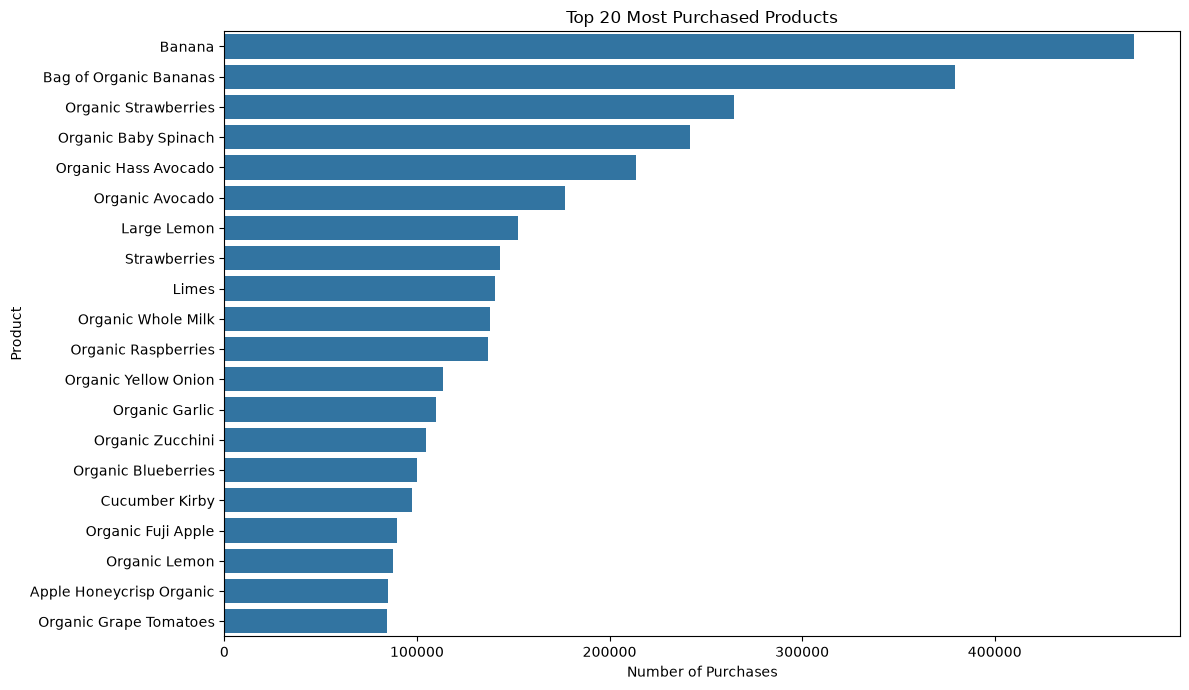

In [28]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products_df,
    x="purchase_count",
    y="product_name"
)

plt.title("Top 20 Most Purchased Products")
plt.xlabel("Number of Purchases")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

## Step 15 — Reorder Analysis

The reorder behavior of customers is analyzed to understand
whether previously purchased products are likely to be purchased again.

In [29]:
# Step 15 - Reorder analysis

reorder_counts = {}

chunksize = 500_000

for chunk in pd.read_csv(
    "../data/raw/order_products__prior.csv",
    usecols=["reordered"],
    chunksize=chunksize
):

    counts = chunk["reordered"].value_counts()

    for value, count in counts.items():
        reorder_counts[value] = (
            reorder_counts.get(value, 0) + count
        )

reorder_counts

{1: 19126536, 0: 13307953}

# Percentage:

In [30]:
total = sum(reorder_counts.values())

reorder_percentage = {
    key: round((value / total) * 100, 2)
    for key, value in reorder_counts.items()
}

print("Reorder percentage:", reorder_percentage)

Reorder percentage: {1: 58.97, 0: 41.03}


# Visualization:

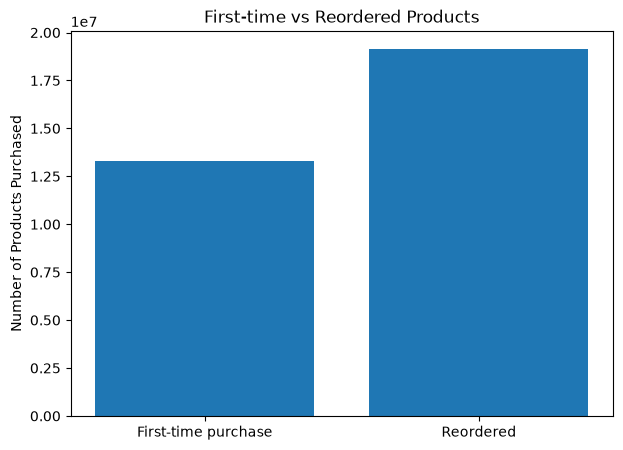

In [31]:
labels = ["First-time purchase", "Reordered"]
values = [
    reorder_counts.get(0, 0),
    reorder_counts.get(1, 0)
]

plt.figure(figsize=(7, 5))

plt.bar(labels, values)

plt.title("First-time vs Reordered Products")
plt.ylabel("Number of Products Purchased")

plt.show()

# Step 16 — Department Analysis

In [32]:
# Step 16 - Product and department relationship

products_department = products.merge(
    departments,
    on="department_id",
    how="left"
)

products_department.head()

,product_id,product_name,aisle_id,department_id,department
0,1,Chocolate Sandwich Cookies,61,19,snacks
1,2,All-Seasons Salt,104,13,pantry
2,3,Robust Golden Unsweetened Oolong Tea,94,7,beverages
3,4,Smart Ones Classic Favorites Mini Rigatoni Wit...,38,1,frozen
4,5,Green Chile Anytime Sauce,5,13,pantry


In [33]:
department_product_count = (
    products_department
    .groupby("department")
    .size()
    .sort_values(ascending=False)
)

department_product_count.head(10)

department
personal care      6563
snacks             6264
pantry             5371
beverages          4365
frozen             4007
dairy eggs         3449
household          3085
canned goods       2092
dry goods pasta    1858
produce            1684
dtype: int64

# Visualization:

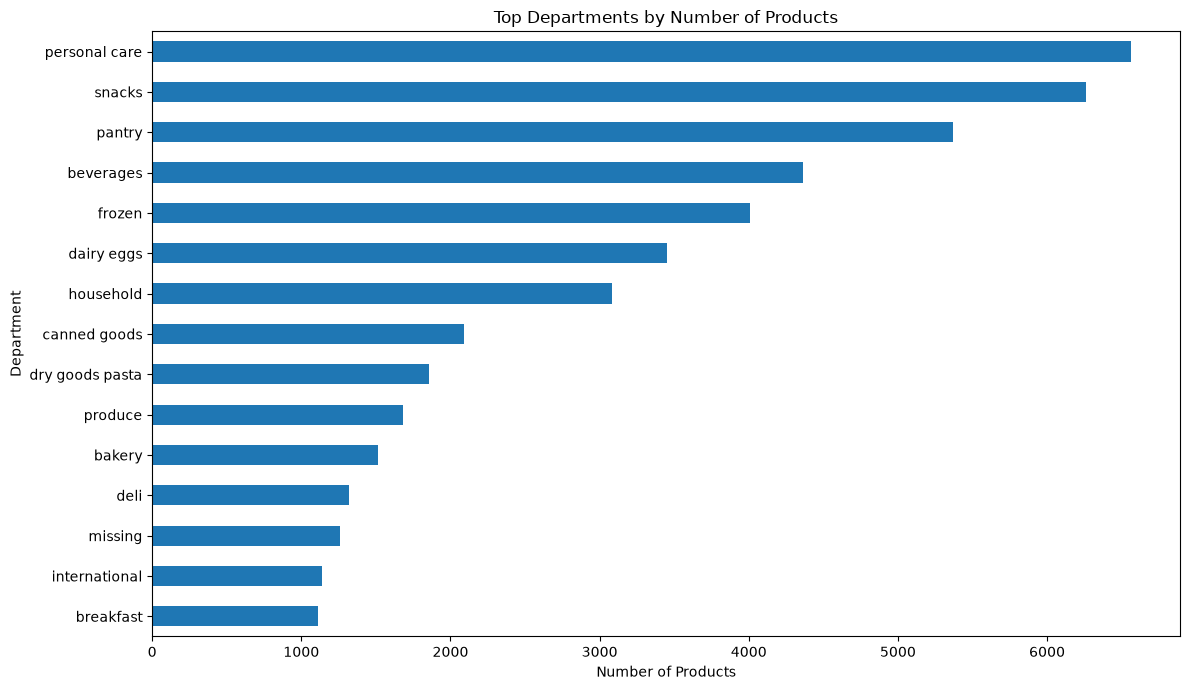

In [34]:
plt.figure(figsize=(12, 7))

department_product_count.head(15).sort_values().plot(
    kind="barh"
)

plt.title("Top Departments by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Department")

plt.tight_layout()
plt.show()

# Step 17 — Aisle Analysis

In [35]:
# Product + aisle relationship

products_aisles = products.merge(
    aisles,
    on="aisle_id",
    how="left"
)

aisle_product_count = (
    products_aisles
    .groupby("aisle")
    .size()
    .sort_values(ascending=False)
)

aisle_product_count.head(20)

aisle
missing                 1258
candy chocolate         1246
ice cream ice           1091
vitamins supplements    1038
yogurt                  1026
chips pretzels           989
tea                      894
packaged cheese          891
frozen meals             880
cookies cakes            874
energy granola bars      832
hair care                816
spices seasonings        797
juice nectars            792
crackers                 747
soup broth bouillon      737
baby food formula        718
coffee                   680
refrigerated             675
cleaning products        655
dtype: int64

# Visualization:

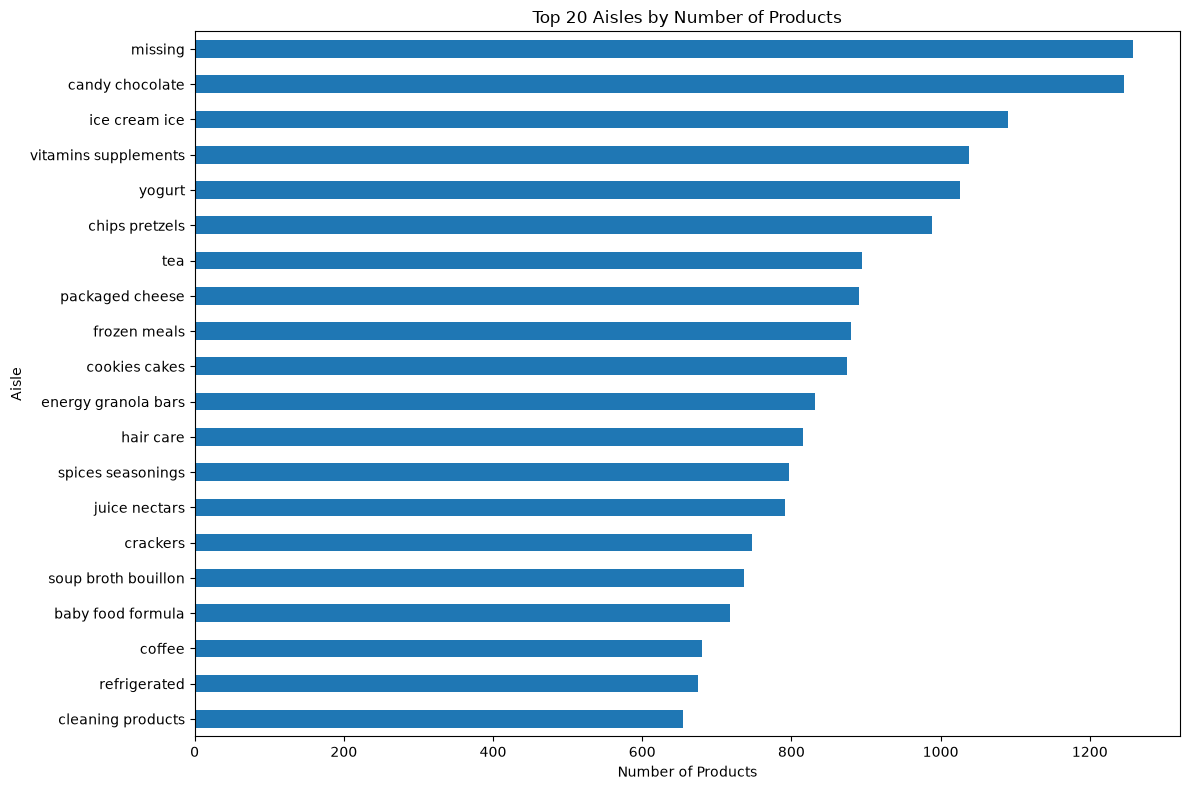

In [36]:
plt.figure(figsize=(12, 8))

aisle_product_count.head(20).sort_values().plot(
    kind="barh"
)

plt.title("Top 20 Aisles by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Aisle")

plt.tight_layout()
plt.show()

# Step 18 — Customer Order Behavior

- user_id
- order_id
- order_number
- order_dow
- order_hour_of_day
- days_since_prior_order

Customer ordering patterns are analyzed based on
day of week, hour of day, and order frequency.

# Orders by hour

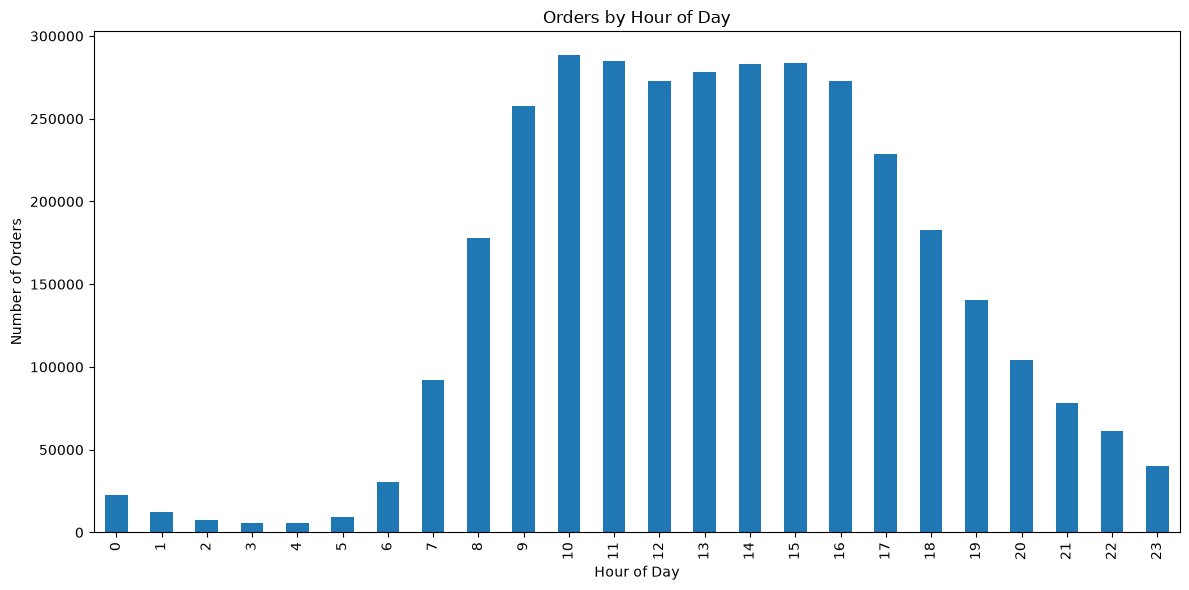

In [37]:
orders_by_hour = (
    orders["order_hour_of_day"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(12, 6))

orders_by_hour.plot(kind="bar")

plt.title("Orders by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

# Orders by day

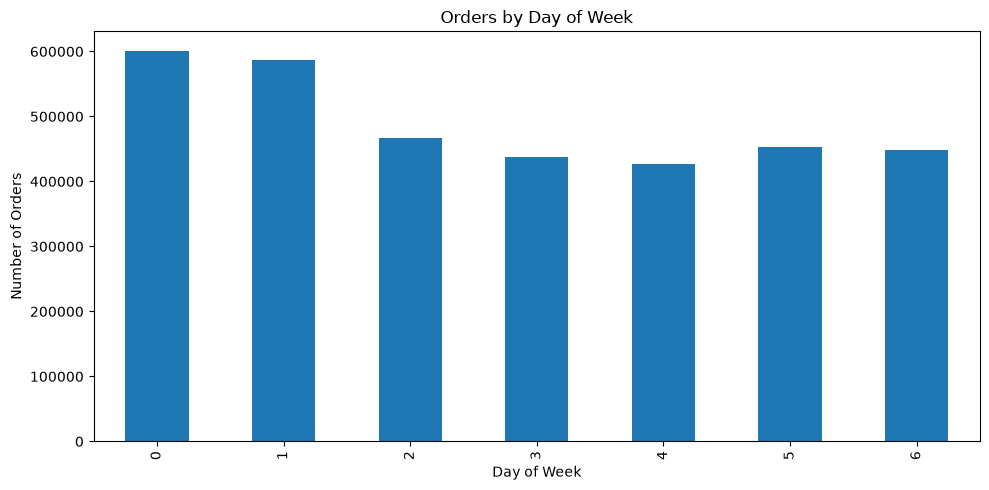

In [38]:
orders_by_day = (
    orders["order_dow"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 5))

orders_by_day.plot(kind="bar")

plt.title("Orders by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

## Step 19 — Market Basket Analysis

Market basket analysis is performed to identify products
that are frequently purchased together.

### Prepare transaction data

In [39]:
# Create transaction-product mapping

basket_data = order_products_train[
    ["order_id", "product_id"]
].copy()

basket_data.head()

,order_id,product_id
0,1,49302
1,1,11109
2,1,10246
3,1,49683
4,1,43633


In [40]:
basket_data = basket_data.merge(
    products[["product_id", "product_name"]],
    on="product_id",
    how="left"
)

basket_data.head()

,order_id,product_id,product_name
0,1,49302,Bulgarian Yogurt
1,1,11109,Organic 4% Milk Fat Whole Milk Cottage Cheese
2,1,10246,Organic Celery Hearts
3,1,49683,Cucumber Kirby
4,1,43633,Lightly Smoked Sardines in Olive Oil


# Step 20 — Create Product Pairs

In [41]:
# Product frequency in training data

train_product_frequency = (
    order_products_train["product_id"]
    .value_counts()
)

train_product_frequency.head(20)

product_id
24852    18726
13176    15480
21137    10894
21903     9784
47626     8135
47766     7409
47209     7293
16797     6494
26209     6033
27966     5546
39275     4966
27845     4908
30391     4613
45007     4589
22935     4290
24964     4158
4920      4059
46979     3868
40706     3823
8518      3818
Name: count, dtype: int64

### Top 100 products:

In [42]:
top_100_product_ids = (
    train_product_frequency
    .head(100)
    .index
)

top_100_basket = basket_data[
    basket_data["product_id"].isin(top_100_product_ids)
]

print("Rows after filtering:", len(top_100_basket))

Rows after filtering: 314227


# Step 21 — Create Basket Matrix

In [43]:
basket_matrix = (
    top_100_basket
    .assign(value=1)
    .pivot_table(
        index="order_id",
        columns="product_name",
        values="value",
        fill_value=0
    )
)

basket_matrix.shape

(93850, 100)

# Step 22 — Frequent Itemsets

In [44]:
pip install mlxtend

Defaulting to user installation because normal site-packages is not writeable
  Using cached mlxtend-0.25.0-py3-none-any.whl.metadata (7.4 kB)
Using cached mlxtend-0.25.0-py3-none-any.whl (1.4 MB)
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from mlxtend.frequent_patterns import fpgrowth

In [46]:
frequent_itemsets = fpgrowth(
    basket_matrix.astype(bool),
    min_support=0.01,
    use_colnames=True
)

frequent_itemsets.sort_values(
    "support",
    ascending=False
).head(20)

,support,itemsets
25,0.199531,(Banana)
0,0.164944,(Bag of Organic Bananas)
22,0.116079,(Organic Strawberries)
39,0.104251,(Organic Baby Spinach)
31,0.086681,(Large Lemon)
62,0.078945,(Organic Avocado)
1,0.077709,(Organic Hass Avocado)
29,0.069196,(Strawberries)
40,0.064283,(Limes)
10,0.059094,(Organic Raspberries)


# Step 23 — Association Rules

In [47]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.20
)

rules = rules.sort_values(
    ["lift", "confidence"],
    ascending=False
)

rules.head(20)

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
16,(Organic Cilantro),(Limes),0.037571,0.064283,0.010730,0.285593,4.442712,1.0,0.008315,1.309780,0.805163,0.117750,0.236513,0.226254
20,(Limes),(Large Lemon),0.064283,0.086681,0.016995,0.264379,3.050030,1.0,0.011423,1.241562,0.718310,0.126859,0.194563,0.230223
3,(Organic Raspberries),(Organic Strawberries),0.059094,0.116079,0.017794,0.301118,2.594081,1.0,0.010935,1.264764,0.653102,0.113067,0.209339,0.227207
4,(Organic Blueberries),(Organic Strawberries),0.052914,0.116079,0.013522,0.255538,2.201414,1.0,0.007379,1.187328,0.576238,0.086971,0.157773,0.186012
22,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.030804,0.164944,0.010368,0.336562,2.040460,1.0,0.005287,1.258679,0.526121,0.055926,0.205516,0.199709
0,(Organic Hass Avocado),(Bag of Organic Bananas),0.077709,0.164944,0.025786,0.331825,2.011743,1.0,0.012968,1.249756,0.545293,0.118901,0.199844,0.244078
10,(Organic Zucchini),(Organic Baby Spinach),0.048897,0.104251,0.010123,0.207017,1.985745,1.0,0.005025,1.129593,0.521932,0.070774,0.114726,0.152057
2,(Organic Raspberries),(Bag of Organic Bananas),0.059094,0.164944,0.018966,0.320952,1.945824,1.0,0.009219,1.229745,0.516607,0.092487,0.186823,0.217970
6,(Organic Cucumber),(Organic Strawberries),0.049153,0.116079,0.010996,0.223716,1.927273,1.0,0.005291,1.138656,0.506004,0.071295,0.121772,0.159223
27,(Organic Fuji Apple),(Banana),0.034704,0.199531,0.012893,0.371508,1.861902,1.0,0.005968,1.273633,0.479558,0.058249,0.214845,0.218062


### Useful columns:

In [48]:
rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(20)

,antecedents,consequents,support,confidence,lift
16,(Organic Cilantro),(Limes),0.010730,0.285593,4.442712
20,(Limes),(Large Lemon),0.016995,0.264379,3.050030
3,(Organic Raspberries),(Organic Strawberries),0.017794,0.301118,2.594081
4,(Organic Blueberries),(Organic Strawberries),0.013522,0.255538,2.201414
22,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.010368,0.336562,2.040460
0,(Organic Hass Avocado),(Bag of Organic Bananas),0.025786,0.331825,2.011743
10,(Organic Zucchini),(Organic Baby Spinach),0.010123,0.207017,1.985745
2,(Organic Raspberries),(Bag of Organic Bananas),0.018966,0.320952,1.945824
6,(Organic Cucumber),(Organic Strawberries),0.010996,0.223716,1.927273
27,(Organic Fuji Apple),(Banana),0.012893,0.371508,1.861902


# Step 24 — Recommendation Function

In [49]:
def recommend_products(product_name, rules, top_n=5):

    recommendations = []

    for _, row in rules.iterrows():

        antecedents = list(row["antecedents"])
        consequents = list(row["consequents"])

        if product_name in antecedents:

            for product in consequents:

                recommendations.append({
                    "product": product,
                    "confidence": row["confidence"],
                    "lift": row["lift"]
                })

    if not recommendations:
        return pd.DataFrame(
            columns=[
                "product",
                "confidence",
                "lift"
            ]
        )

    result = pd.DataFrame(recommendations)

    result = (
        result
        .sort_values(
            ["lift", "confidence"],
            ascending=False
        )
        .drop_duplicates("product")
        .head(top_n)
    )

    return result

### test

In [50]:
# Example recommendation

product_name = top_products_df.iloc[0]["product_name"]

print("Selected product:", product_name)

recommend_products(
    product_name,
    rules,
    top_n=5
)

Selected product: Banana


,product,confidence,lift


# Step 25 — Better Recommendation Function

In [51]:
def get_recommendations(product_name, top_n=5):

    result = recommend_products(
        product_name,
        rules,
        top_n=top_n
    )

    return result

### test:

In [52]:
get_recommendations(
    product_name,
    top_n=10
)

,product,confidence,lift


# Step 26 — Recommendation Evaluation

The recommendation system is evaluated using association
rule metrics such as support, confidence, and lift.

In [53]:
print("Number of frequent itemsets:", len(frequent_itemsets))
print("Number of association rules:", len(rules))

print(
    "Average support:",
    round(rules["support"].mean(), 4)
)

print(
    "Average confidence:",
    round(rules["confidence"].mean(), 4)
)

print(
    "Average lift:",
    round(rules["lift"].mean(), 4)
)

Number of frequent itemsets: 144
Number of association rules: 29
Average support: 0.0156
Average confidence: 0.2669
Average lift: 1.7654


### test:

In [54]:
rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift"
    ]
].head(10)

,antecedents,consequents,support,confidence,lift
16,(Organic Cilantro),(Limes),0.010730,0.285593,4.442712
20,(Limes),(Large Lemon),0.016995,0.264379,3.050030
3,(Organic Raspberries),(Organic Strawberries),0.017794,0.301118,2.594081
4,(Organic Blueberries),(Organic Strawberries),0.013522,0.255538,2.201414
22,(Organic Large Extra Fancy Fuji Apple),(Bag of Organic Bananas),0.010368,0.336562,2.040460
0,(Organic Hass Avocado),(Bag of Organic Bananas),0.025786,0.331825,2.011743
10,(Organic Zucchini),(Organic Baby Spinach),0.010123,0.207017,1.985745
2,(Organic Raspberries),(Bag of Organic Bananas),0.018966,0.320952,1.945824
6,(Organic Cucumber),(Organic Strawberries),0.010996,0.223716,1.927273
27,(Organic Fuji Apple),(Banana),0.012893,0.371508,1.861902


# Step 27 — Save Recommendation Model

In [55]:
import joblib

In [56]:
joblib.dump(
    rules,
    "../models/association_rules.pkl"
)

print("Recommendation model saved successfully!")

Recommendation model saved successfully!


In [57]:
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(
    rules,
    "../models/association_rules.pkl"
)

print("Model saved successfully!")

Model saved successfully!
